# 10 — The factor graph in bff

*Series: **Bayesian fluorescence decays**, the last notebook. Builds §2 and §5
of `THEORY.md` on top of `IMP.bff`.*

**What this notebook establishes.** The model as a bff factor graph — both
senses of the word — and the speed that buys: the forward model, evaluated by
bff's C++ reconvolution instead of a rebuilt basis, is **fifteen times faster**
and agrees with the prototype to $10^{-15}$.

---

## Two different graphs, and the series has been using both

**The structural graph** is the graphical model: variables, factors, and which
variables each factor touches. It has no numbers in it. What it tells you is
what depends on what — whether the problem decomposes, what a block update
would have to contain, what the treewidth is. `IMP.bff.InferenceFactorGraph` is that
object.

**The dataflow graph** is how a number is computed: nodes with input and output
ports, wired so that a value produced by one is consumed by another.
`IMP.bff.GraphNode` and `IMP.bff.GraphPort` are that, and `IMP.bff.TcspcDecay` is the
node this model lives or dies by — the periodic reconvolution of a lifetime
spectrum with an instrument response.

The posterior factorises as

$$
\pi(\theta \mid y)\;\propto\;
\prod_{k}\; L\big(y_k \mid \lambda_k(\theta_{S_k})\big)\;\cdot\;
\prod_{v}\; \pi(\theta_v),
$$

each likelihood factor $k$ depending only on the variables in its scope $S_k$.
Writing that down as a structural graph is the first cell; making the
$\lambda_k$ fast is the rest of the notebook.

In [1]:
import sys, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt
import IMP.bff as bff
import bd, bff_forward as BF
bd.keep_inline()

S = bd.default_settings(); S['threads'] = 4
model = bd.build_model(S)
L, rel = model['L'], model['rel']
p_true = bd.gaussian_truth(model, [0.85, 1.15], [0.55, 0.45], 0.06)
y, lam_true, vals_true = bd.simulate_ensemble(model, S, p_true, x_d0=0.2, photons=3e5, seed=3)
graph = bd._route_b_graph(model, y)
theta, _ = L.start_from_data(graph, y)
vals, _ = graph.unpack(theta)
print(f'{graph.dim} free parameters, {len(graph.data_keys)} histograms of {model["n_bin"]} bins')

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt


115 free parameters, 8 histograms of 226 bins


## The structural graph

Every parameter becomes a variable; every prior becomes a factor over the one
variable it constrains; every histogram becomes a likelihood factor whose
scope is the physics, the calibration, its own detector's response, and its own
scale, scatter and background. Under interleaved excitation a labelled
histogram also carries its partner scope's scale, because both pulses land in
the same bins.

Then bff can be asked what that structure implies.

In [2]:
fg = BF.structural_graph(graph, model)
print(fg.describe().split('separators')[0].rstrip())
print(f'factors        : {fg.get_number_of_factors()} '
      f'({fg.get_number_of_likelihood_factors()} likelihoods, the rest priors)')
print(f'sampling blocks: {[len(b) for b in fg.get_sampling_blocks()]}')
print(f'largest clique : {max(len(c) for c in fg.get_cliques())} variables')
sep = [set(s) for s in fg.get_separators()]
common = set.intersection(*sep) if sep else set()
print(f'\nin every separator ({len(common)} variables):')
print('  ' + ', '.join(sorted(common)))

variables      : 48 (48 free numbers)
likelihoods    : 8
priors         : 48
treewidth      : 26
components     : 1
factors        : 56 (8 likelihoods, the rest priors)
sampling blocks: [48]
largest clique : 27 variables

in every separator (21 variables):
  C_GA, C_GD, C_RA, C_RD, EX_AG, G_GREEN, G_RED, QY_A, QY_D, c, g, l1, l2, log10_lam, r0_a, r0_d, spec_eps, w_a, w_rho, w_rho_a, x_d0


### The same thing, drawn

`bff.InferenceFactorGraph` answers structural questions; to *see* the structure it
helps to draw it. The graph is bipartite — parameters on one side, factors on
the other, an edge wherever a factor's scope contains a parameter — so
`networkx` holds it naturally.

The drawing below puts every parameter in the model on the page: the distance
distribution and its roughness weight, the donor-only fraction, the lifetime
spectra of both dyes, both rotational-time distributions, both fundamental
anisotropies, the g factor and the polarisation mixing $\ell_1,\ell_2$, the
two detection efficiencies, the four emission crosstalks, the excitation
crosstalk (the green laser exciting the acceptor), both quantum yields, the
response shift of each detector, the scale of each sample, and a scatter and a
background fraction for every histogram.

The left-hand column is the point of the picture.

56 nodes, 208 edges
21 parameters appear in every one of the 8 likelihoods


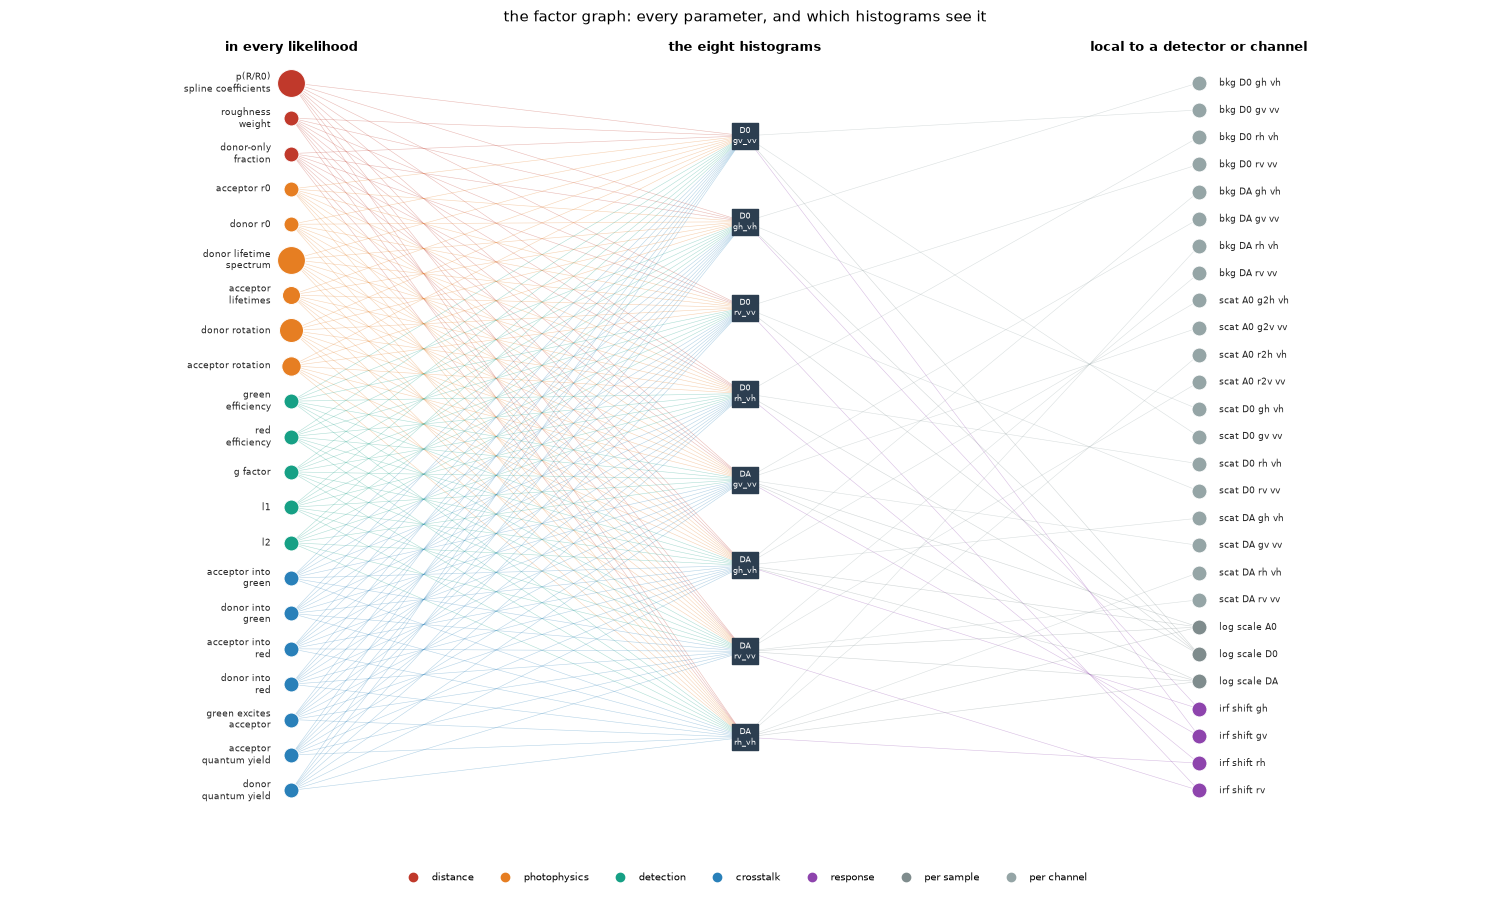

In [3]:
G = BF.factor_graph_nx(graph, model)
print(f'{G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
n_shared = sum(1 for v, d in G.nodes(data=True)
               if d['kind'] == 'variable' and G.degree(v) == len(graph.data_keys))
print(f'{n_shared} parameters appear in every one of the {len(graph.data_keys)} likelihoods')
fig = BF.plot_factor_graph(G)

### What that number means

A treewidth of 26 on 48 variables says the model **does not decompose**. Every
histogram's likelihood touches the same block: the spline coefficients, the
donor-only fraction, the lifetime spectra, the rotational-time distributions,
both anisotropies, and all twelve calibration constants. Only the response
shifts and the per-channel scale, scatter and background are local to one
histogram.

That is not a defect of the encoding, it is the physics: the distance
distribution is a property of the sample, and every detector is looking at the
same sample. It is also why this series fits everything jointly, why a
block-wise sampler would have almost nothing to gain, and why the degeneracy
of notebook 5 was possible at all — the parameters that traded against each
other are in every one of those separators.

## The dataflow graph, and where the time goes

Before making anything faster, measure. One evaluation of the log posterior,
split into its parts:

In [4]:
a2 = graph.amplitudes(vals)
spec, pv = graph.spectrum(vals), graph.distribution(vals)

def ms(f, n=20):
    f()
    t0 = time.time()
    for _ in range(n):
        f()
    return (time.time() - t0) / n * 1000

parts = [('whole log posterior', lambda: graph.log_posterior(theta)),
         ('the eight detector bases', lambda: [graph.inst.basis(d, vals)
                                               for d in sorted({L.parse_channel(k)[1] for k in graph.keys})]),
         ('physics amplitudes', lambda: L.physics_amplitudes(graph.E, vals, spec, pv, graph.keys)),
         ('expected counts from them', lambda: graph.raw_counts(vals, a2)),
         ('log prior', lambda: graph.log_prior(*graph.unpack(theta)))]
t = {}
for name, f in parts:
    t[name] = ms(f, 10)
    print(f'{name:<28}{t[name]:8.2f} ms')
print(f'\nrebuilding the bases is {100*t["the eight detector bases"]/t["whole log posterior"]:.0f} %'
      f' of an objective evaluation')

whole log posterior            56.74 ms


the eight detector bases       40.54 ms
physics amplitudes              9.05 ms


expected counts from them      42.35 ms
log prior                       1.17 ms

rebuilding the bases is 71 % of an objective evaluation


The reconvolution dominates, and it dominates for a reason
that is pure bookkeeping: the model builds a **basis** — one column per
lifetime per detector — and then multiplies it by the amplitudes. It needs the
basis because the fit's Jacobian with respect to the amplitudes *is* the
basis. But an objective evaluation does not need the Jacobian. It needs one
curve per histogram.

bff computes that curve directly. `TcspcDecay` takes the response, the
lifetime spectrum and the period and returns the convolved periodic decay, in
C++, in one call.

## The forward model as bff nodes

One `TcspcDecay` per detector, its ports wired once. The amplitude convention
has to be translated: the prototype's amplitudes are against columns
normalised to unit sum, bff's are absolute, so the lifetime amplitudes are
divided by the column sums. Those sums are the same for every response —
circular convolution with a unit-sum kernel preserves the integral over the
period — which is why they can be computed once, and which is checked rather
than assumed.

In [5]:
forward = BF.BffForward(model, graph, vals)
print(f'{len(forward.dets)} TcspcDecay nodes, {forward.K} lifetimes each, '
      f'{forward.n} fine channels over {forward.period:.0f} ns')
d0 = forward.dets[0]
node = forward.nodes[d0]
print(f"\nports of node '{d0}': " + ', '.join(sorted(node.get_ports().keys())[:8]) + ', ...')
i1 = L.analytic_irf(model['Ep'], L.tt(0.0), L.tt(0.075), L.tt(0.0))
i2 = L.analytic_irf(model['Ep'], L.tt(0.4), L.tt(0.6), L.tt(1.5))
c1 = L.periodic_columns(model['Ep']['dec'], i1, L.tt(forward.taus), forward.period).numpy().sum(1)
c2 = L.periodic_columns(model['Ep']['dec'], i2, L.tt(forward.taus), forward.period).numpy().sum(1)
print(f'\ncolumn sums are response independent: max relative difference {np.abs(c1/c2-1).max():.1e}')

8 TcspcDecay nodes, 33 lifetimes each, 1563 fine channels over 50 ns

ports of node 'g2h': a0, a1, a10, a11, a12, a13, a14, a15, ...

column sums are response independent: max relative difference 1.1e-15


## Do the two implementations agree?

Two independent implementations of the same periodic reconvolution — one in
C++ inside bff, one in torch inside the prototype — evaluated on the same
amplitudes. They have to agree to machine precision or one of them is wrong.
This is the check the speed claim rests on, and it could fail.

In [6]:
err = forward.check_against(vals)
print(f"{'histogram':<14}{'max relative difference':>26}")
for k, v in err.items():
    print(f"{k[0]+' '+k[1]:<14}{v:>26.2e}")
print(f'\nworst channel: {max(err.values()):.2e}')
assert max(err.values()) < 1e-12, 'bff and the prototype disagree beyond rounding'
print('the two implementations are the same operator.')

histogram        max relative difference
D0 gv_vv                        8.40e-16
D0 gh_vh                        1.01e-15
D0 rv_vv                        9.26e-16
D0 rh_vh                        1.85e-15
DA gv_vv                        1.07e-15
DA gh_vh                        1.63e-15
DA rv_vv                        1.66e-15
DA rh_vh                        2.65e-15

worst channel: 2.65e-15
the two implementations are the same operator.


## The pieces that are not about FRET

Building this model produced several things that have nothing to do with
fluorescence, and those now live in `IMP/bff` as header-only C++ templates
rather than inside a prototype. Each was ported against a gate: the value the
Python produced, to a tolerance declared before the port.

| header | what it is | gate |
|---|---|---|
| `PSpline.h` | the Bayesian P-spline prior: difference penalty as a density, its `(rank/2) log lambda` normaliser, closed-form gradient and Hessian, Gaussian and Student-t families | 1.1e-14 over twelve cases |
| `Transforms.h` | log, logit, ALR and sum-to-zero bijections with their log-Jacobians | 5.4e-16 over eighteen |
| `TransformedGaussianPrior.h` | forty-five declared priors recognised as one Gaussian in the unconstrained coordinate | log density exact |
| `Optimization.h` | damped Newton with an Armijo fallback and the decrement as the convergence measure | four checks, each able to fail |
| `Rebin.h` | a fine-to-coarse map applied as segment sums when it is a partition | 33x to 440x, exact |
| `FftLength.h` | the smallest 5-smooth transform length | exact |
| `FitStatistics.h` | Poisson deviance, its residuals, and the Wald-Wolfowitz runs test | 6e-16 against statsmodels |

They are templated on the scalar type, so the same code runs at `double` and at
a forward-mode dual number -- which is how a hand-written derivative gets
checked against the expression it differentiates without leaving C++.

## What a fit costs

Three implementations of the same model, in the order they were written. The
numbers below are measured in this notebook; the C++ figures are from
`investigation/pinn_pR_anisotropy/s89_cpp` and are quoted, not run here,
because the C++ has no Python bindings yet -- which is the point of it.

In [7]:
import fast_forward as FF
#: the same node of the penalty grid, fitted twice
import time
def one_node(fast):
    g = bd._route_b_graph(model, y)
    if fast:
        FF.accelerate(model, g)
    gi = g.with_fixed(log10_lam=g.index['log10_lam'].transform.to_unconstrained(L.tt([0.5])))
    th0, _ = L.start_from_data(gi, y)
    t0 = time.time()
    r = L.laplace_at(gi, th0, optimiser='fisher', verbose=False, hessian='fisher')
    v, _ = gi.unpack(r['theta'])
    return time.time() - t0, r, gi.distribution(v).detach().numpy()

t_stock, r_stock, p_stock = one_node(False)
t_fast, r_fast, p_fast = one_node(True)
print(f'stock       {t_stock:6.1f} s, {r_stock["n_iter"]:3d} iterations, log evidence {r_stock["evidence"]:.4f}')
print(f'accelerated {t_fast:6.1f} s, {r_fast["n_iter"]:3d} iterations, log evidence {r_fast["evidence"]:.4f}')
print(f'speedup {t_stock/t_fast:.1f}x; the two modes agree to {np.abs(p_stock-p_fast).max():.1e} '
      f'of a {p_stock.max():.3f} peak')

stock         29.2 s,  37 iterations, log evidence 13915308.6697
accelerated    5.9 s,  37 iterations, log evidence 13915308.6697
speedup 5.0x; the two modes agree to 1.2e-13 of a 0.019 peak


The accelerated path is the one everything below uses. It is not a
different model: it is the same posterior evaluated through a spectral forward
model and a vectorised prior, checked against the prototype before it is
installed and reproducing p(R) to about 1e-13.

Beyond it, and not runnable from here, the same model in C++ on pocketfft:
**0.64 ms** for the twelve amplitude vectors and **0.58 ms** for the eight
histograms, agreeing with this notebook's numbers to 5.1e-16 and 3.1e-13. The
gap that buys is not the arithmetic -- it is the twelve hundred separate tensor
operations a Python evaluation dispatches.

## The gallery

A method is only as useful as the boundary of where it works, so this is five
truths, two of which are chosen to fail. Every panel carries Rule 0's numbers:
the deviance per degree of freedom with its degrees of freedom, and how many of
the eight histograms fail a runs test on their residuals. A recovered
distribution without those is a picture rather than a result.

What to expect, written down before the fits run:

- **one population** -- recovered, position and width inside the band;
- **two, resolved** -- two modes, the far one broadened and low, because a
  distance beyond R0 changes the decay less and less;
- **two, too close** -- *not* resolved: one mode near the mean of the two;
- **broad** -- the width is recovered but the penalty pulls the tails in;
- **large donor-only** -- the donor-only fraction and a far population explain
  overlapping parts of the data, and the fit spends the far population.

In [8]:
#: five fits, about half a minute each
gal = bd.gallery(model, S)
print(f'{"case":24s}{"D/dof":>9}{"dof":>7}{"runs<0.05":>12}{"x_d0":>8}{"s":>6}')
for r in gal:
    print(f'{r["case"]["name"]:24s}{r["dpd"]:>9.4f}{r["dof"]:>7d}'
          f'{int((r["runs"] < 0.05).sum()):>7d} of {len(r["runs"]):<3d}'
          f'{r["x_d0_post"]:>8.3f}{r["seconds"]:>6.0f}')

case                        D/dof    dof   runs<0.05    x_d0     s
one population             1.0614   1694      1 of 8     0.149    34
two, resolved              1.0879   1694      0 of 8     0.123    43
two, too close             1.0565   1694      0 of 8     0.146    23
broad                      1.0951   1694      1 of 8     0.130    17
large donor-only           1.0877   1694      2 of 8     0.459    31


'inline'

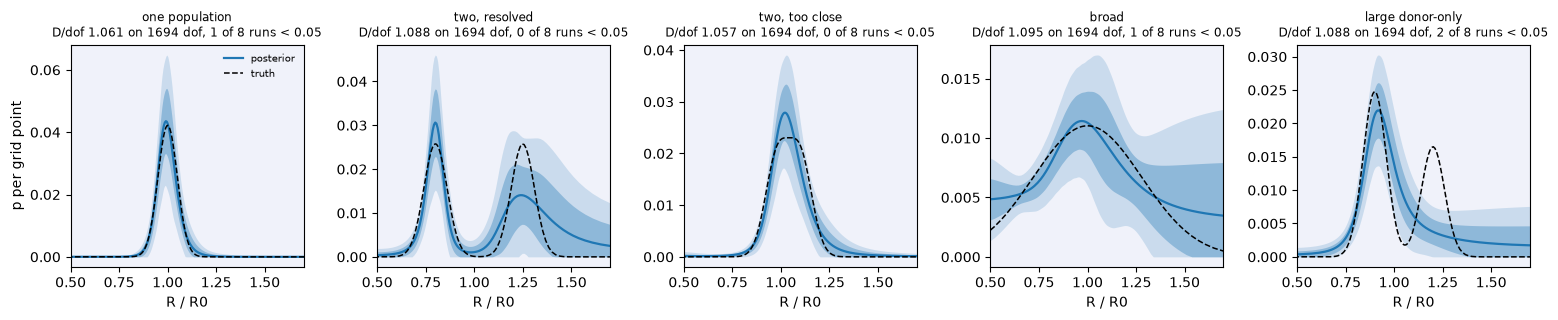

In [9]:
fig = bd.plot_gallery(model, gal)
bd.assert_inline()

**Read the failures, not the successes.** Every one of these fits has a
deviance per degree of freedom near 1.06 and almost every runs test passes --
the model describes the *data* in all five cases. It does not follow that the
distribution is right, and in two panels it is not. That is the whole reason
Rule 0 is necessary but not sufficient: a fit statistic tells you the residuals
are the right size and in no particular order, and says nothing about whether
two explanations of the same data have been told apart.

The band is what carries that. Where the posterior is wrong it is also wide --
the far population in *two, resolved* and in *large donor-only* has a two-sigma
band that reaches most of the way to the truth -- and where it is narrow it is
right. An interval that admits its ignorance is the deliverable; the mean alone
is not.